# Titanic (End To End ML Workflow)

# Introduction

**Titanic: Machine Learning from Disaster** is one of the best Kaggle competitions for improving data science skills, especially, feature engineering skills. The Titanic dataset is a pretty good choice for beginners who want to improve data science skills.

In this project, I will deal with the end-to-end data science cycle. And this project will include the below sections.

### Table of Contents:

* 1. Preprocessing the data
    * 1.1 Variable Explanations
    * 1.2 Importing Libraries
    * 1.3 Getting Data
    * 1.4 Overview of The Data
    
* 2. Exploratory Data Analaysis
    * 2.1 Missing Values
        * 2.1.1 Age 
        * 2.1.2 Embarked
        * 2.1.3 Cabin
        * 2.1.4 Fare
    * 2.2 Outliers    
    * 2.3 Analyzing Target Variable
    * 2.4 Analyzing Features
        * 2.4.1 Categorical Features
        * 2.4.2 Continuous Features
    * 2.4 Exploring Correlations
        
* 3. Feature Engieering
    * 3.1 Binning Continuous Features
    * 3.2 Creating New Features
    * 3.3 Feature Selecting
    * 3.4 Feature Scaling(Continuous Variables)
    * 3.5 Feature Transformation (Categoric Variables)
    
* 4. Model Selecting And Model Tuning
    * 4.1 Model Training
    * 4.2 Model Tuning

* 5. Making a Submission

# 1. Data Preprocessing

## 1.1 Variable Explanations

First of all we need to get some information about data.
 


 * **PassengerId:**  Unique Id for each passenger (it doesn't have any effect on target)
 
    
 * **Survived(categorical):** Survival (0 : No, 1 : Yes) (*)
 
 
 * **Pclass(categorical-ordinal) :**	Passenger class (1 : 1st, 2 : 2nd, 3 : 3rd)
 
 
 * **Name:** Passenger name
 
 
 * **Sex(categorical) :** Passenger sex
 
 
 * **Age:** Passenger age
 
 
 * **SibSp:** Sibling - Spouse (**)	
 
 
 * **Parch:** Parent - Child (***)
 
 
 * **Ticket:** Ticket number
 
 
 * **Fare:** Passenger fare
 
 
 * **Cabin:** Cabin number
 
 
 * **Embarked(categorical):** Port of Embarkation (C 
 : Cherbourg, Q : Queenstown, S : Southampton)
 

(*) 'Survived 'is the target variable we are trying to predict. So test data doesn't have 'Survived' column.


(**) sibsp: The dataset defines family relations in this way...

           Sibling = brother, sister, stepbrother, stepsister

           Spouse = husband, wife (mistresses and fiancés were ignored)

(***) parch: The dataset defines family relations in this way...

            Parent = mother, father

            Child = daughter, son, stepdaughter, stepson

            ! Some children travelled only with a nanny, therefore parch=0 for them.

## 1.2 Importing Libraries

In [1]:
# data processing
import numpy as np
import pandas as pd 

# data visualization
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as plt

# Algorithms
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB

# Model Selection
from sklearn import model_selection
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import metrics
from sklearn.preprocessing import StandardScaler,minmax_scale

import warnings
warnings.filterwarnings("ignore")

## 1.3 Getting Data

In [2]:
# reading data
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')

In [3]:
train_df = train.copy()
test_df = test.copy()
df = train_df.append(test_df,sort=False)

## 1.4 Overview of The Data

In [4]:
train_df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
764,765,0,3,"Eklund, Mr. Hans Linus",male,16.0,0,0,347074,7.7750,NaN,S
564,565,0,3,"Meanwell, Miss. (Marion Ogden)",female,NaN,0,0,SOTON/O.Q. 392087,8.0500,NaN,S
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S
826,827,0,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S


In [5]:
test_df.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
335,1227,1,"Maguire, Mr. John Edward",male,30.0,0,0,110469,26.0000,C106,S
330,1222,2,"Davies, Mrs. John Morgan (Elizabeth Agnes Mary...",female,48.0,0,2,C.A. 33112,36.7500,NaN,S
112,1004,1,"Evans, Miss. Edith Corse",female,36.0,0,0,PC 17531,31.6792,A29,C
402,1294,1,"Gibson, Miss. Dorothy Winifred",female,22.0,0,1,112378,59.4000,NaN,C
253,1145,3,"Salander, Mr. Karl Johan",male,24.0,0,0,7266,9.3250,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [8]:
print('train dataset has ' + str(train_df.shape[0]) + ' observations ' + str(train_df.shape[1])+ ' variables.')
print('test dataset has ' + str(test_df.shape[0]) + ' observations ' + str(test_df.shape[1])+ ' variables.')

train dataset has 891 observations 12 variables.
test dataset has 418 observations 11 variables.


In [9]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [11]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


When I look at the statistical summary of the data, I notice a few things :
* Approximately 38% of the passengers survived. 
* It looks like Fare variable contains outlier observations.
* The majority of passengers travel alone.
* The majority of passengers are less than 40 years old
    
These are the things I understand when I first look at the data. I will review the data in more detail later. 

## 2. Exploratory Data Analysis

## 2.1 Missing Values

In [12]:
train_df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
Fare             0
Ticket           0
Parch            0
SibSp            0
Sex              0
Name             0
Pclass           0
Survived         0
PassengerId      0
dtype: int64

In [13]:
def explore_missing_values(df) :
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total,percent], axis=1, keys=['Total','Percent'])
    sns.barplot(x=missing_data.index,y=missing_data['Percent'])
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Percent of Missing Values')
    plt.title('PERCENT MISSING DATA BY FEATURE')
    plt.xticks(rotation='75')
    plt.show()
    print(missing_data.head(20))

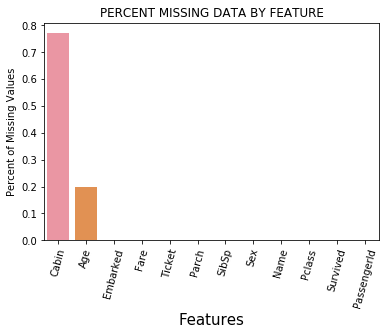

             Total   Percent
Cabin          687  0.771044
Age            177  0.198653
Embarked         2  0.002245
Fare             0  0.000000
Ticket           0  0.000000
Parch            0  0.000000
SibSp            0  0.000000
Sex              0  0.000000
Name             0  0.000000
Pclass           0  0.000000
Survived         0  0.000000
PassengerId      0  0.000000


In [14]:
explore_missing_values(train_df)

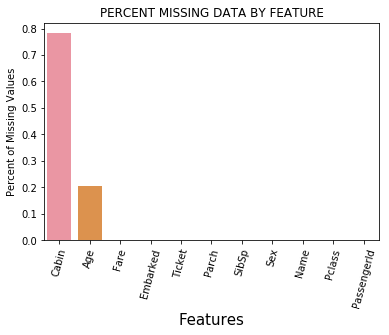

             Total   Percent
Cabin          327  0.782297
Age             86  0.205742
Fare             1  0.002392
Embarked         0  0.000000
Ticket           0  0.000000
Parch            0  0.000000
SibSp            0  0.000000
Sex              0  0.000000
Name             0  0.000000
Pclass           0  0.000000
PassengerId      0  0.000000


In [15]:
explore_missing_values(test_df)

The number of missing values in the Age, Embarked and Fare columns is relatively low compared to the total number of observations. Therefore, missing values in those columns can simply fill with descriptive statistics measurements.But, it is not the right approach for the 'Cabin' column that includes approximately %80 missing values. 

#### 2.1.1 Age

I will create Title feature for imputing Age columns, but I won't use that feature in the model.

In [16]:
def create_Title(df):
    titles = {
        "Mr" :         "Mr",
        "Mme":         "Mrs",
        "Ms":          "Mrs",
        "Mrs" :        "Mrs",
        "Master" :     "Master",
        "Mlle":        "Miss",
        "Miss" :       "Miss",
        "Capt":        "Rare",
        "Col":         "Rare",
        "Major":       "Rare",
        "Dr":          "Rare",
        "Rev":         "Rare",
        "Jonkheer":    "Rare",
        "Don":         "Rare",
        "Sir" :        "Rare",
        "Countess":    "Rare",
        "Dona":        "Rare",
        "Lady" :       "Rare"
    }
    extracted_titles = df["Name"].str.extract(' ([A-Za-z]+)\.',expand=False)
    df["Title"] = extracted_titles.map(titles)

In [17]:
create_Title(train_df)
create_Title(test_df)

In [18]:
train_df.groupby('Title')['Age'].median()

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [19]:
df.corr()['Age'].abs().sort_values(ascending=False)

Age            1.000000
Pclass         0.408106
SibSp          0.243699
Fare           0.178740
Parch          0.150917
Survived       0.077221
PassengerId    0.028814
Name: Age, dtype: float64

In [20]:
train_df.groupby(['Title','Pclass'])['Age'].median()

Title   Pclass
Master  1          4.0
        2          1.0
        3          4.0
Miss    1         30.0
        2         24.0
        3         18.0
Mr      1         40.0
        2         31.0
        3         26.0
Mrs     1         40.0
        2         31.5
        3         31.0
Rare    1         48.5
        2         46.5
Name: Age, dtype: float64

Pclass and Age have high correlation so decided to group the data by Title and Pclass and fill the Age column with the median of each group.

In [21]:
# Imputing 'Age' features

train_df["Age"] =train_df.groupby(['Title','Pclass'])["Age"].apply(lambda x : x.fillna(x.median()))
test_df["Age"] = test_df.groupby(['Title','Pclass'])["Age"].apply(lambda x : x.fillna(x.median()))

#### 2.1.2 Embarked

In [22]:
train_df[train_df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,Miss
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,Mrs


When I googled that names I learned that they boarded the Titanic in from Southampton. I will fill missing values in 'Embarked' with 'S' representing 'Southampton'.

https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html

In [23]:
#Imputing 'Embarked' features
train_df["Embarked"] = train_df["Embarked"].fillna("S")

#### 2.1.3 Cabin

In [24]:
train_df[train_df['Cabin'].isnull()].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
5,6,0,3,"Moran, Mr. James",male,26.0,0,0,330877,8.4583,NaN,Q,Mr
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master


Although the 'Cabin' feature has too much missing value, for now, I won't drop the column and I will fill them with 'U0'  representing that they are unknown,  after then I will try to extract useful information from the 'Cabin' column.

In [25]:
#Imputing 'Cabin' features
train_df["Cabin"] = train_df["Cabin"].fillna("S")
test_df["Cabin"] = test_df["Cabin"].fillna("S")

#### 2.1.4 Fare

In [26]:
df.corr()['Fare'].abs().sort_values(ascending = False)

Fare           1.000000
Pclass         0.558629
Survived       0.257307
Parch          0.221539
Age            0.178740
SibSp          0.160238
PassengerId    0.031428
Name: Fare, dtype: float64

In [27]:
test_df[test_df['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,S,S,Mr


In [28]:
test_df[test_df['Ticket']=='3701']

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,S,S,Mr


In [29]:
#Imputing 'Fare' features
test_df["Fare"] = test_df.groupby(['Pclass'])["Fare"].apply(lambda x : x.fillna(x.median()))

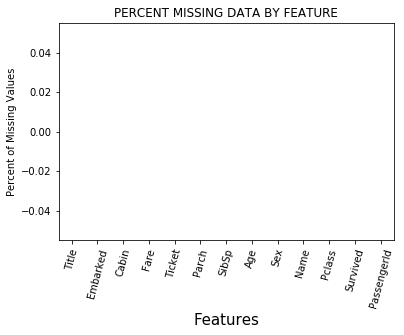

             Total  Percent
Title            0      0.0
Embarked         0      0.0
Cabin            0      0.0
Fare             0      0.0
Ticket           0      0.0
Parch            0      0.0
SibSp            0      0.0
Age              0      0.0
Sex              0      0.0
Name             0      0.0
Pclass           0      0.0
Survived         0      0.0
PassengerId      0      0.0


In [30]:
explore_missing_values(train_df)

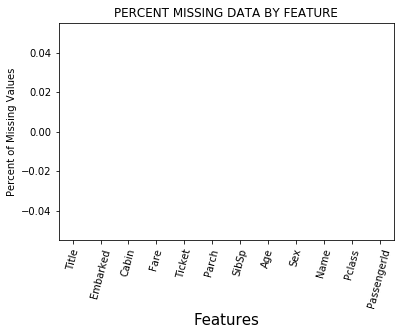

             Total  Percent
Title            0      0.0
Embarked         0      0.0
Cabin            0      0.0
Fare             0      0.0
Ticket           0      0.0
Parch            0      0.0
SibSp            0      0.0
Age              0      0.0
Sex              0      0.0
Name             0      0.0
Pclass           0      0.0
PassengerId      0      0.0


In [31]:
explore_missing_values(test_df)

## 2.2 Outliers

### Fare

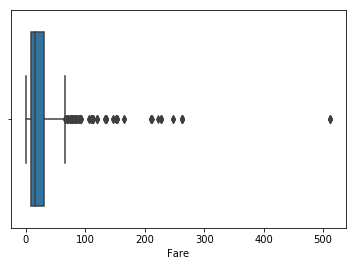

In [32]:
sns.boxplot(x=train_df['Fare']);

In [33]:
Q1 = train_df['Fare'].quantile(0.05)
Q3 = train_df['Fare'].quantile(0.95)
IQR = Q3-Q1

In [34]:
top_border_fare = Q3+1.5*IQR
top_border_fare

269.360375

In [35]:
train_df.loc[train_df['Fare'] > top_border_fare,'Fare'] = top_border_fare
test_df.loc[test_df['Fare'] > top_border_fare,'Fare'] = top_border_fare

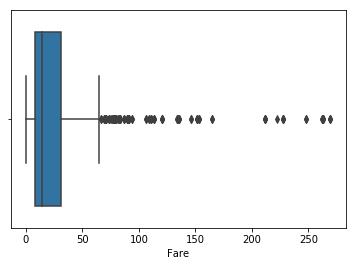

In [36]:
sns.boxplot(x=train_df['Fare']);


## 2.3 Exploring Target Variable

In [37]:
train_df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [38]:
train_df['Survived'].describe().T

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

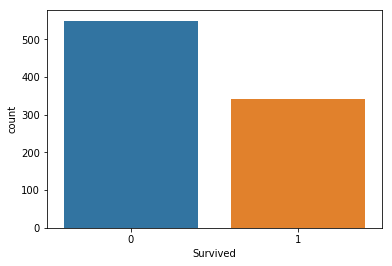

In [39]:
sns.countplot(x='Survived',data=train)

## 2.4 Analyzing Features 

In [40]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,S,Mr


In [41]:
categorical_features = ['Pclass','Sex','SibSp','Parch','Embarked']
continuous_features =['Age','Fare']

### 2.4.1 Categorical Features

In [42]:
def visualize_categorical_columns(df,col_list,hue='Survived'):
    for col in col_list:
        # hue='Survived'
        sns.countplot(x=col,data=df,hue=hue)
        plt.show()
    return

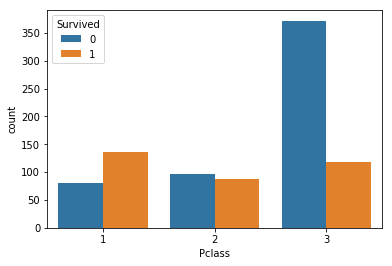

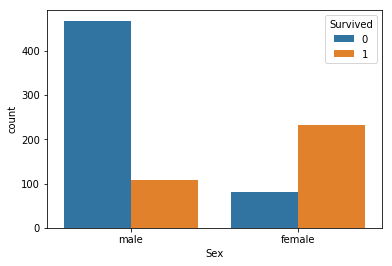

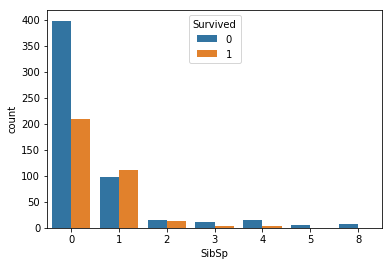

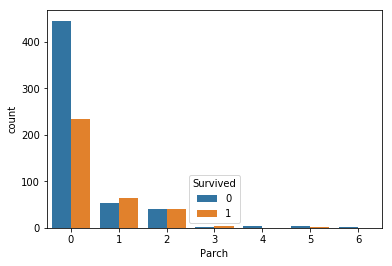

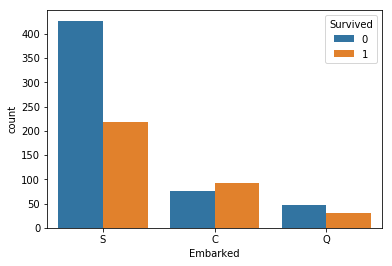

In [43]:
visualize_categorical_columns(train_df, categorical_features)

###  2.4.2 Continuous Features 

In [44]:
def visuzalize_continuous_columns(df,col_list):
    for col in col_list:
        sns.distplot(df[col])
        plt.show()
    return

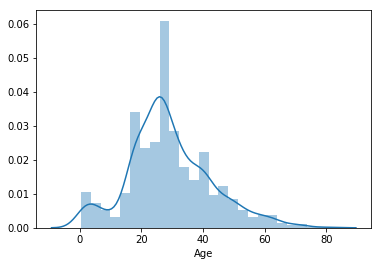

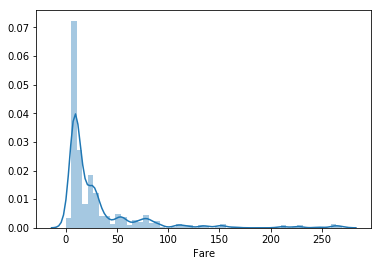

In [45]:
 visuzalize_continuous_columns(train_df, continuous_features )

## 2.5 Exploring Correlations

In [46]:
corr = train_df.corr()
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.042749,-0.057527,-0.001652,0.006212
Survived,-0.005007,1.000000,-0.338481,-0.062756,-0.035322,0.081629,0.270884
Pclass,-0.035144,-0.338481,1.000000,-0.415221,0.083081,0.018443,-0.600003
Age,0.042749,-0.062756,-0.415221,1.000000,-0.270812,-0.184551,0.130178
SibSp,-0.057527,-0.035322,0.083081,-0.270812,1.000000,0.414838,0.191866
Parch,-0.001652,0.081629,0.018443,-0.184551,0.414838,1.000000,0.248858
Fare,0.006212,0.270884,-0.600003,0.130178,0.191866,0.248858,1.000000


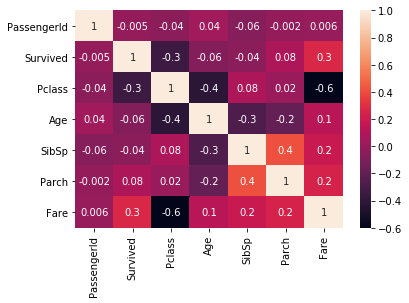

In [47]:
sns.heatmap(train_df.corr(), annot = True, fmt='.1g')

In [48]:
corr['Survived'].abs().sort_values().abs().sort_values(ascending = False)

Survived       1.000000
Pclass         0.338481
Fare           0.270884
Parch          0.081629
Age            0.062756
SibSp          0.035322
PassengerId    0.005007
Name: Survived, dtype: float64

# 3. Feature Engineering

## 3.1 Binning Continuous Features

In [49]:
# Binning 'Age' column
train_df['AgeBinCode'] = LabelEncoder().fit_transform(pd.qcut(train_df["Age"],4))
test_df['AgeBinCode'] = LabelEncoder().fit_transform(pd.qcut(test_df["Age"],4))

train_df['AgeBinCode'].value_counts()

0    241
3    223
2    220
1    207
Name: AgeBinCode, dtype: int64

(array([0, 1, 2, 3]), <a list of 4 Text xticklabel objects>)

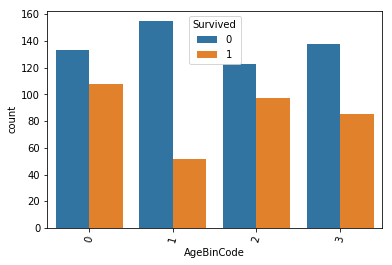

In [50]:
sns.countplot(x=train_df['AgeBinCode'], hue='Survived', data=train_df)
plt.xticks(rotation='75')

In [51]:
# Binning 'Fare' column
train_df['FareBinCode'] = LabelEncoder().fit_transform(pd.qcut(train_df["Fare"],5))
test_df['FareBinCode'] = LabelEncoder().fit_transform(pd.qcut(test_df["Fare"],5))

train_df['FareBinCode'].value_counts()

1    184
3    180
0    179
4    176
2    172
Name: FareBinCode, dtype: int64

(array([0, 1, 2, 3, 4]), <a list of 5 Text xticklabel objects>)

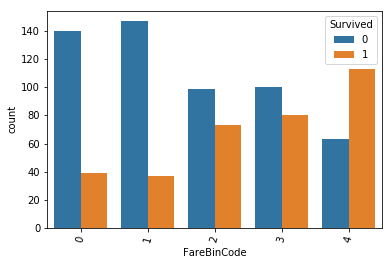

In [52]:
sns.countplot(x=train_df['FareBinCode'], hue='Survived', data=train_df)
plt.xticks(rotation='75')

## 3.2 Creating New Features

In [53]:
# Creating FamilySize features
train_df['FamilySize'] = train_df['Parch'] + train_df['SibSp']
test_df['FamilySize'] = test_df['Parch'] + test_df['SibSp']

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]), <a list of 9 Text xticklabel objects>)

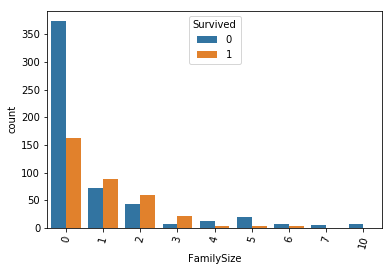

In [54]:
sns.countplot(x=train_df['FamilySize'], hue='Survived', data=train_df)
plt.xticks(rotation='75')

In [55]:
# Creating LastName features
train_df['LastName'] = train_df['Name'].apply(lambda x: str.split(x, ",")[0])
test_df['LastName'] =test_df['Name'].apply(lambda x: str.split(x, ",")[0]) 
df['LastName'] = df['Name'].apply(lambda x: str.split(x, ",")[0])

This feature is from Konstantin's kernel. FamilySurvival variable gathers together families and people with the same ticket and gives a ratio about group survival.
https://www.kaggle.com/konstantinmasich/titanic-0-82-0-83

In [56]:
#Creating FamilySurvival features

DEFAULT_SURVIVAL_VALUE = 0.5

df['FamilySurvival'] = DEFAULT_SURVIVAL_VALUE

for grp, grp_df in df[['Survived', 'Name', 'LastName', 'Fare', 'Ticket', 'PassengerId',
                            'SibSp', 'Parch', 'Age', 'Cabin']].groupby(['LastName', 'Fare']):
    

    if (len(grp_df) != 1):
        # A Family group is found.
        for ind, row in grp_df.iterrows():
            smax = grp_df.drop(ind)['Survived'].max()
            smin = grp_df.drop(ind)['Survived'].min()
            passID = row['PassengerId']
            if (smax == 1.0):
                df.loc[df['PassengerId'] == passID, 'Family_Survival'] = 1
            elif (smin == 0.0):
                df.loc[df['PassengerId'] == passID, 'Family_Survival'] = 0

print("Number of passengers with family survival information:",
      df.loc[df['FamilySurvival'] != 0.5].shape[0])



for _, grp_df in df.groupby('Ticket'):
    if (len(grp_df) != 1):
        for ind, row in grp_df.iterrows():
            if (row['FamilySurvival'] == 0) | (row['FamilySurvival'] == 0.5):
                smax = grp_df.drop(ind)['Survived'].max()
                smin = grp_df.drop(ind)['Survived'].min()
                passID = row['PassengerId']
                if (smax == 1.0):
                    df.loc[df['PassengerId'] == passID, 'FamilySurvival'] = 1
                elif (smin == 0.0):
                    df.loc[df['PassengerId'] == passID, 'FamilySurvival'] = 0

print("Number of passenger with family/group survival information: "
      + str(df[df['FamilySurvival'] != 0.5].shape[0]))



train_df['FamilySurvival'] = df['FamilySurvival'][:891]
test_df['FamilySurvival'] = df['FamilySurvival'][891:]


Number of passengers with family survival information: 0
Number of passenger with family/group survival information: 496


##  3.3 Feature Selecting

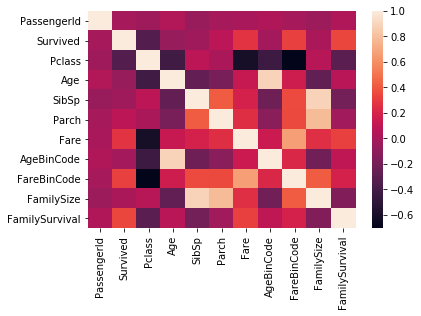

In [57]:
sns.heatmap(train_df.corr())

In [58]:
train_df.corr()['Survived'].abs().sort_values(ascending=False)

Survived          1.000000
FamilySurvival    0.343614
Pclass            0.338481
FareBinCode       0.317783
Fare              0.270884
Parch             0.081629
Age               0.062756
SibSp             0.035322
FamilySize        0.016639
AgeBinCode        0.008391
PassengerId       0.005007
Name: Survived, dtype: float64

In [59]:
features = ['Pclass', 'Sex', 'AgeBinCode', 'FareBinCode', 'FamilySurvival','FamilySize']
target = ['Survived']


In [60]:
# X_train, X_test, y_train

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]


## 3.5 Feature Transformation (Categoric Variables)

In [61]:
X_train.head()

,Pclass,Sex,AgeBinCode,FareBinCode,FamilySurvival,FamilySize
0,3,male,1,0,0.5,1
1,1,female,3,4,0.5,1
2,3,female,1,1,0.5,0
3,1,female,2,4,0.0,1
4,3,male,2,1,0.5,0


In [62]:
def create_dummies(df,categorical_features):
    for column_name in categorical_features:
        dummies = pd.get_dummies(df[column_name], prefix=column_name, drop_first=True)
        df = pd.concat([df,dummies],axis=1)
    return df

In [63]:
X_train['Sex'] = LabelEncoder().fit_transform(X_train['Sex'])
X_test['Sex'] = LabelEncoder().fit_transform(X_test['Sex'])

In [64]:
X_test.head()

,Pclass,Sex,AgeBinCode,FareBinCode,FamilySurvival,FamilySize
0,3,1,2,1,0.5,0
1,3,0,3,0,0.5,1
2,2,1,3,1,0.5,0
3,3,1,2,1,0.5,0
4,3,0,0,2,1.0,2


## 3.4 Feature Scaling(Continuous Variables)

In [65]:
X_train =StandardScaler().fit_transform(X_train)
y_train = train_df[target]
X_test = StandardScaler().fit_transform(X_test)

# 4. Modelling

## 4.1 Model Training

In [66]:
models = [
    ('KNN',KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('SVM',SVC()),
    ('RF', RandomForestClassifier()),
]

results = []
names = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state=7)
    cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")
    results.append(cv_results)
    names.append(name)
    print("%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()))


KNN: 0.839526 (0.026476)
DT: 0.833945 (0.022990)
NB: 0.759863 (0.050807)
SVM: 0.832747 (0.019932)
RF: 0.846267 (0.018568)


## 4.2 Model Tuning

In [67]:
def tuning_model(model,hyperparams_dict):
    grid = GridSearchCV(model,
                        param_grid=hyperparams_dict,
                        cv=10,
                        n_jobs=-1,
                        verbose=2)
    grid.fit(X_train, y_train)
    best_params = grid.best_params_
    best_score = grid.best_score_
  
    print("Best Score: {}".format(best_score))
    print("Best Parameters: {}\n".format(best_params))

    return grid.best_estimator_

#### KNN

In [68]:
knn_hyperparams = { "n_neighbors" : list(range(1,30,1)),
"algorithm" : ['auto'],
"weights" : ['uniform', 'distance'],
"leaf_size" : list(range(1,50,5))
}

knn_tuned = tuning_model(KNeighborsClassifier(),knn_hyperparams)

Fitting 10 folds for each of 580 candidates, totalling 5800 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 1772 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 5020 tasks      | elapsed:   19.8s


Best Score: 0.8519101123595506
Best Parameters: {'algorithm': 'auto', 'leaf_size': 11, 'n_neighbors': 6, 'weights': 'distance'}



[Parallel(n_jobs=-1)]: Done 5800 out of 5800 | elapsed:   23.0s finished


#### RANDOM FOREST

In [69]:
rf_hyperparams = {"n_estimators": [40, 60, 90],
"criterion": ["entropy", "gini"],
"max_depth": [2, 5, 10],
"max_features": ["log2", "sqrt"],
"min_samples_leaf": [1, 5, 8],
"min_samples_split": [2, 3, 5] }

rf_tuned = tuning_model(RandomForestClassifier(), rf_hyperparams)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 10 folds for each of 324 candidates, totalling 3240 fits


[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 300 tasks      | elapsed:   19.3s
[Parallel(n_jobs=-1)]: Done 706 tasks      | elapsed:   43.8s
[Parallel(n_jobs=-1)]: Done 1108 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 1473 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1918 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 2445 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 3052 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 3240 out of 3240 | elapsed:  3.5min finished


Best Score: 0.8552434456928838
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 90}



# 5. Making A Submission

In [70]:
def save_submission_file(model,X_test,filename="submission.csv"):
    submission_df = {"PassengerId": test['PassengerId'],
                     "Survived": model.predict(X_test)}
    submission = pd.DataFrame(submission_df)
    submission.to_csv(filename,index=False)

In [71]:
save_submission_file(knn_tuned,X_test,filename='knn_submission.csv')

In [72]:
save_submission_file(rf_tuned,X_test,filename='rf_submission.csv')